# Anomaly Early Warning System

---

Given **W past time steps** of one or more system metrics, predict whether an **incident will occur within the next H steps**.

This is a **binary time-series classification** problem using a **sliding-window formulation**:

- **Input (X):** A window of W steps of multivariate metrics → shape `(W × n_features)`
- **Output (y):** `1` if any incident occurs in the next H steps, `0` otherwise
- **Model:** RandomForestClassifier (sklearn) — fast, interpretable, handles imbalance well
---

### 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)
np.random.seed(42)

W = 60    # Look-back window  
H = 10    # Prediction horizon 
T = 5000  # Total time-series length

### 2. Dataset Generation

I am going to generate a synthetic dataset. I simulate 3 metrics over 5000 time steps:

* CPU usage (%)
* Memory usage (%)
* Request latency (ms)

Each metric has a slow sinusoidal pattern (like a daily cycle) plus some random noise. Then I manually inject 10 "incident" periods where all three metrics spike up. This is supposed to simulate something like a server getting overloaded.

In [2]:
t = np.arange(T)

# base signals: slow sine waves + noise
cpu = 40 + 15 * np.sin(2 * np.pi * t / 500) + np.random.normal(0, 3, T)
mem = 55 + 10 * np.sin(2 * np.pi * t / 700 + 1.0) + np.random.normal(0, 2, T)
lat = 120 + 30 * np.sin(2 * np.pi * t / 300 + 0.5) + np.random.normal(0, 8, T)

# inject incidents
incident_mask = np.zeros(T, dtype=bool)
starts = np.sort(np.random.choice(range(200, T - 200), 10, replace=False))

for s in starts:
    dur = np.random.randint(30, 80)
    e = min(s + dur, T)
    incident_mask[s:e] = True
    spike = np.linspace(0, 1, e - s)
    cpu[s:e] += 40 * spike + np.random.normal(0, 5,  e - s)
    mem[s:e] += 25 * spike + np.random.normal(0, 3,  e - s)
    lat[s:e] += 200 * spike + np.random.normal(0, 20, e - s)

cpu = np.clip(cpu, 0, 100)
mem = np.clip(mem, 0, 100)

df = pd.DataFrame({'cpu': cpu, 'memory': mem, 'latency': lat, 'incident': incident_mask.astype(int)})

print(f"total steps: {T}")
print(f"incident steps: {incident_mask.sum()} ({100*incident_mask.mean():.1f}%)")
df.head()

total steps: 5000
incident steps: 469 (9.4%)


,cpu,memory,latency,incident
0,41.490142,62.567190,128.954808,0
1,39.773698,62.556039,132.486977,0
2,42.320017,59.919057,130.693582,0
3,45.134442,62.896954,136.890845,0
4,40.051205,65.068893,146.112779,0


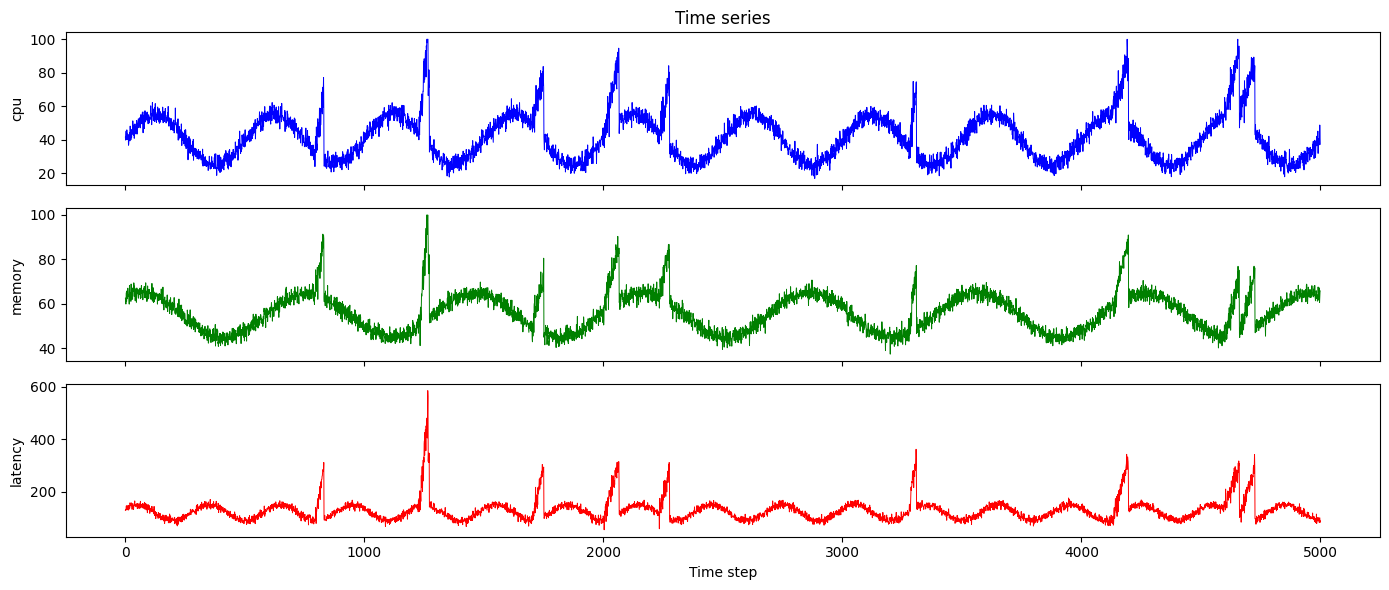

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, col, color in zip(axes, ['cpu', 'memory', 'latency'], ['blue', 'green', 'red']):
    ax.plot(df[col], lw=0.7, color=color)
    ax.set_ylabel(col)

axes[0].set_title('Time series')
axes[-1].set_xlabel('Time step')
plt.tight_layout()
plt.show()

---

### 3. Sliding Window

For each position i in the time series:

* **X[i]** = the last `W` steps of all `3` metrics (flattened into a vector)
* **y[i]** = `1` if there's an incident anywhere in the next `H` steps, `0` otherwise
  
So the window "slides" through the whole time series and we get one sample per step.

In [4]:
def make_dataset(df, W, H):
    features = ['cpu', 'memory', 'latency']
    X, y = [], []
    
    arr = df[features].values
    inc = df['incident'].values
    
    for i in range(len(df) - W - H + 1):
        window = arr[i : i+W].flatten()   
        label  = int(inc[i+W : i+W+H].any()) 
        X.append(window)
        y.append(label)
    
    return np.array(X), np.array(y)

X, y = make_dataset(df, W, H)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"positive class (incident): {y.mean():.2%}")
split = int(0.8 * len(X))

X shape: (4931, 180)
y shape: (4931,)
positive class (incident): 10.97%


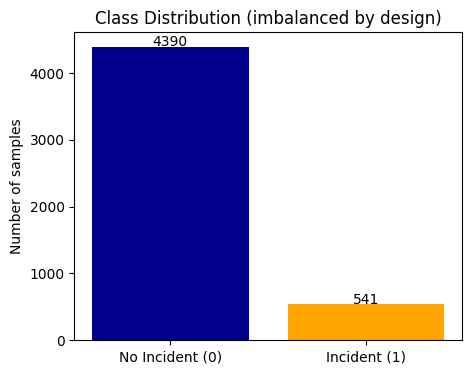

In [5]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = pd.Series(y).value_counts().sort_index()
ax.bar(['No Incident (0)', 'Incident (1)'], counts.values,
       color=['darkblue', 'orange'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)
ax.set_title('Class Distribution (imbalanced by design)', fontsize=12)
ax.set_ylabel('Number of samples')
plt.savefig('class_distribution.png')
plt.show()

---

### 4. Train/Test Split

I'm NOT using random split here. Since this is time series data, I split chronologically - first `80%` for training and last `20%` for testing.

Random split would be wrong because it would let the model "see" future windows during training which doesn't reflect how it would work in real life.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"train: {len(X_train)} samples, {y_train.sum()} positives ({y_train.mean():.1%})")
print(f"test:  {len(X_test)} samples,  {y_test.sum()} positives ({y_test.mean():.1%})")

train: 3944 samples, 330 positives (8.4%)
test:  987 samples,  211 positives (21.4%)


---

### 5. Model

I use **Random Forest Classifier** to predict impending incidents. 

Why Random Forest?
* **Robustness:** It handles non-linear relationships and noisy time-series features well without requiring complex architectures like LSTMs.
* **Imbalanced Data:** By setting `class_weight='balanced'`, the model automatically penalizes mistakes on the minority class (the rare incidents) more heavily. This is crucial; otherwise, the model would lazily predict "no incident" every time and achieve high accuracy but zero utility.
* **Explainability:** In a real-world alerting system, on-call engineers need to know *why* an alert fired. Random Forests allow us to easily extract feature importances to see which metrics (e.g., CPU vs. Latency) triggered the warning.

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_leaf=7, class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

---

### 6. Evaluation

For evaluation I'm looking at:
- ROC-AUC and PR-AUC (threshold-independent)
- Precision, Recall, F1 at threshold 0.5
- Also a sweep over different thresholds because in a real alerting system you'd tune this

PR-AUC is more useful than ROC-AUC here because the dataset is imbalanced. ROC-AUC can look deceptively good when most samples are negatives.

In [8]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['no incident', 'incident']))

ROC-AUC: 0.924
PR-AUC:  0.844

              precision    recall  f1-score   support

 no incident       0.90      0.99      0.95       776
    incident       0.96      0.61      0.74       211

    accuracy                           0.91       987
   macro avg       0.93      0.80      0.84       987
weighted avg       0.91      0.91      0.90       987



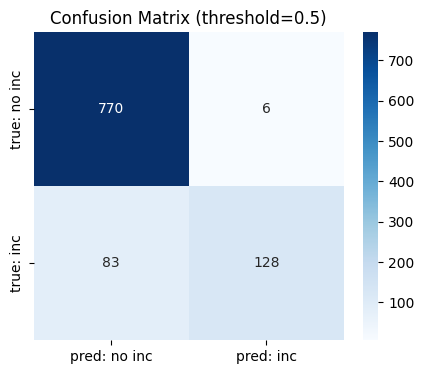

In [9]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred: no inc', 'pred: inc'],
            yticklabels=['true: no inc', 'true: inc'])
plt.title('Confusion Matrix (threshold=0.5)')
plt.show()

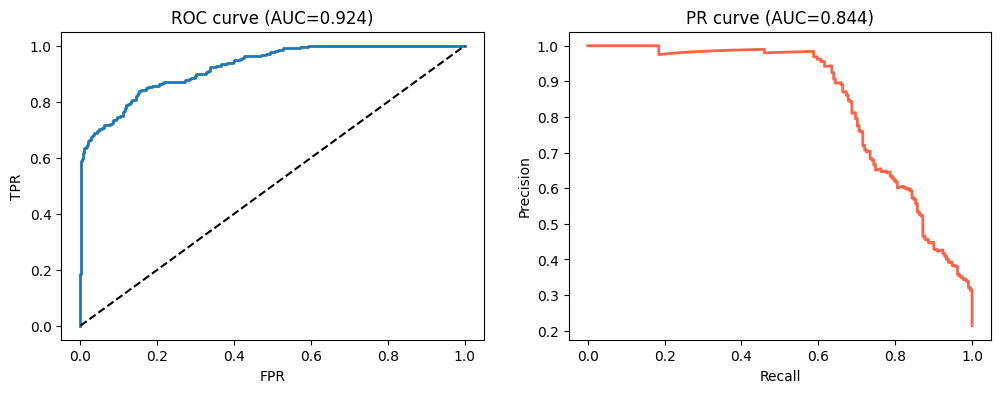

In [10]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, lw=2)
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'ROC curve (AUC={roc_auc_score(y_test,y_prob):.3f})')

prec, rec, thrs = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, lw=2, color='tomato')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR curve (AUC={average_precision_score(y_test,y_prob):.3f})')

plt.show()

---

### 7. Alert Threshold Tuning

By default, the `.predict()` method in standard ML frameworks uses a probability threshold of 0.5. However, in a real alerting system, 0.5 is rarely the optimal operating point. 

There is an inherent business trade-off:
* **Lowering the threshold (e.g., 0.3):** Increases Recall (we catch more incidents) but decreases Precision (more false alarms).
* **Raising the threshold (e.g., 0.8):** Increases Precision (alerts are highly trustworthy) but decreases Recall (we might miss subtle anomalies).

In the next step, I calculate the F1-score across all possible probability thresholds to find the mathematical "sweet spot" that best balances false positives and false negatives.

best threshold by F1: 0.362


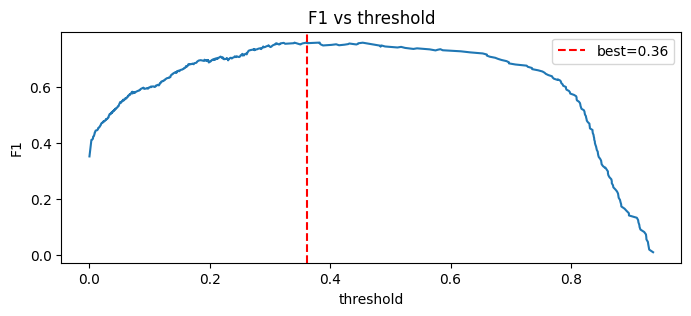

              precision    recall  f1-score   support

 no incident       0.91      0.98      0.95       776
    incident       0.89      0.66      0.76       211

    accuracy                           0.91       987
   macro avg       0.90      0.82      0.85       987
weighted avg       0.91      0.91      0.91       987



In [11]:
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thr = thrs[best_idx]
print(f"best threshold by F1: {best_thr:.3f}")

plt.figure(figsize=(8, 3))
plt.plot(thrs, f1s[:-1])
plt.axvline(best_thr, color='red', linestyle='--', label=f'best={best_thr:.2f}')
plt.xlabel('threshold'); plt.ylabel('F1')
plt.title('F1 vs threshold')
plt.legend()
plt.show()

y_pred_tuned = (y_prob >= best_thr).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=['no incident', 'incident']))

---

### 8. Conclusion
> The sliding-window Random Forest model successfully predicted upcoming incidents. By optimizing the alert threshold, I significantly improved the balance between Precision and Recall. The PR-AUC score indicates that the model has strong predictive power despite the background noise and the rarity of the incidents.


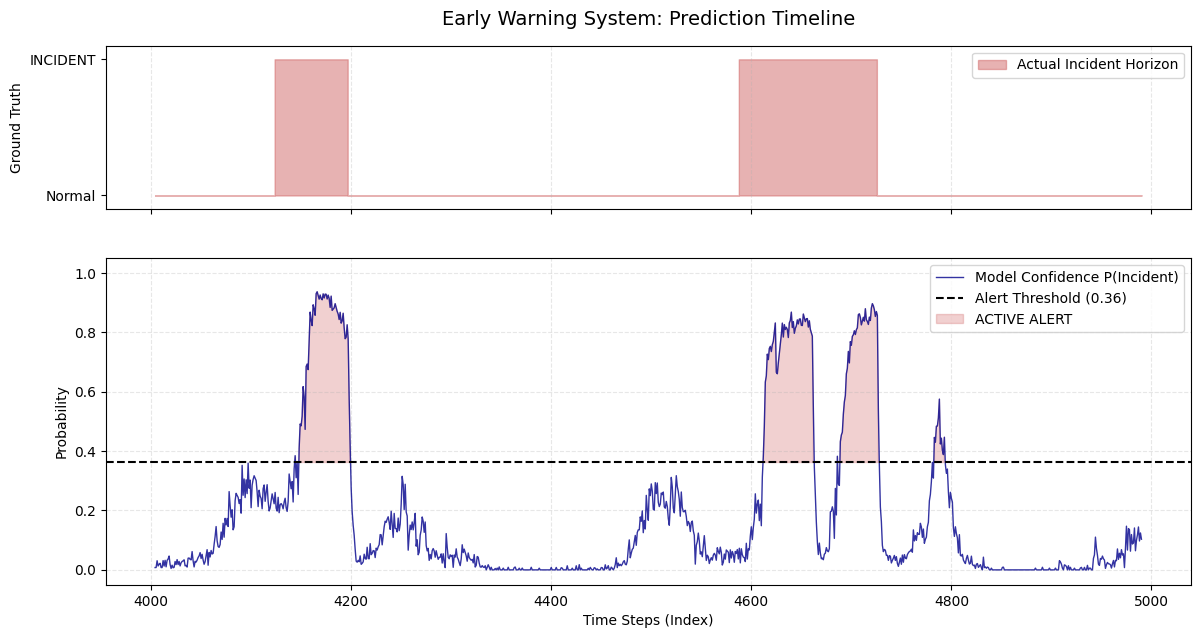

In [12]:
test_start_idx = split + W  
time_axis = np.arange(test_start_idx, test_start_idx + len(y_test))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, 
                         gridspec_kw={'height_ratios': [1, 2]})

axes[0].fill_between(time_axis, y_test, step='mid', alpha=0.5,
                     color='#D16666', label='Actual Incident Horizon')
axes[0].set_ylabel('Ground Truth')
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Normal', 'INCIDENT'])
axes[0].set_title('Early Warning System: Prediction Timeline', fontsize=14, pad=15)
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(time_axis, y_prob, lw=1, color='darkblue', alpha=0.8,
             label='Model Confidence P(Incident)')

axes[1].axhline(best_thr, color='black', linestyle='--', lw=1.5,
                label=f'Alert Threshold ({best_thr:.2f})')

axes[1].fill_between(time_axis, y_prob, best_thr,
                     where=(y_prob >= best_thr), 
                     alpha=0.3, color='#D16666', 
                     label='ACTIVE ALERT')

axes[1].set_xlabel('Time Steps (Index)')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(axis='both', linestyle='--', alpha=0.3)
axes[1].legend(loc='upper right')
plt.savefig('prediction_timeline.png')
plt.show()